In [1]:
#class to both save inference log to file and visualise it in the notebook
import sys
import os

class Tee:
    def __init__(self, filename, mode="a"):
        self.file = open(filename, mode)
        self.stdout = sys.stdout
        
    def write(self, data):
        self.stdout.write(data)
        self.file.write(data)
        self.flush()

    def flush(self):
        self.stdout.flush()
        self.file.flush()

    def __enter__(self):
        sys.stdout = self
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout = self.stdout
        self.file.close()

In [2]:
import sys
import os
sys.path.append(os.path.abspath('./src')) 
from personalise_to_QRS import run_qrs_personalization
from personalise_to_Twave import run_twave_personalization
from datetime import datetime
from path_config import set_path_mapping, get_path_mapping

path_mapping = get_path_mapping()
# --- CONFIGURAZIONE DELL'ESPERIMENTO ---
subject = 'sb4301'
current_month = datetime.now().strftime('%h') 
current_year = datetime.now().strftime('%Y') 
#define unique tag to preserve history of results for same subject DEFAULT: Month_year
base_configs = {
    'exp_unique_tag': current_month + '_' + current_year,
    'verbose': True,
    'source_resolution': 'coarse1500cm'
}

# parameters for clinical ecg processing
qrs_clinical_config = {
    'clinical_ecg_filename': 'sb4301_scaled_norm11_CVcamps2_fast4x_grad10_purk300_realprep.csv', #name clinical ecg file in the folder /data/clinical_data
    'filtering': False, #filtering for the input ecg signal
    'low_freq_cut': 0.5, 
    'high_freq_cut': 150,
    'normalise': True, #normalising for clinical ecg signal
    'zero_align': True, 
    'frequency': 1000,  # This is only used for filtering. If you dont use 1000 Hz in any time-series in the code, the other hyper-parameters will not give the expected outcome!
    'max_len_qrs': 200,  # in ms. This is used to crop the QRS complex from the ECG signal. It should be long enough to capture the entire QRS complex, but not too long to include the T-wave.
    'lead_names': ['I', 'II', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
}
# default speed values for the fibre, normal and purkinje velocities. These are fixed during the inference, but can be changed here if desired.
# only the sheet, endo_dense and endo_sparse speeds are inferred
qrs_fixed_speed_config = {
    'fibre_speed': 0.065,  # cm/ms, Taggart et al. (2000)
    'normal_speed': 0.048,  # cm/ms, Taggart et al
    'purkinje_speed': 0.3  # cm/ms, average speed value
}
# population ranges and priors for speed and root nodes inference 
qrs_inference_speed_config = {
    'sheet_speed_range': [0.025, 0.06],  # cm
    'sheet_speed_prior': None,  # [mean, std]
    'dense_endo_speed_range': [0.1, 0.19],  # cm/ms
    'dense_endo_speed_prior': None,  # [mean, std]
    'sparse_endo_speed_range': [0.07, 0.15],  # cm/ms
    'sparse_endo_speed_prior': None,  # [mean, std]
    'nb_root_nodes_range': [4, 9],  # min/max -> 10 is computationally intractable
    'nb_root_node_prior': [6, 1],  # [mean, std]
}

# parameters for SMC-ABC inference
qrs_smc_inference_config = {
    'population_size': 120,
    'max_mcmc_steps': 50,   # This number allows for extensive exploration
    'retain_ratio': 0.5,    # proportion of samples that would match the current data in the case of N_on = 1 and all particles having the same variable switched on.
    'max_root_node_jiggle_rate': 0.1,
    'desired_discrepancy': 1.0,
    'max_process_alive_time': 12., # hours max inference time limit
    'unique_stopping_ratio': 0.5, # if only 50% of the population is unique, then terminate the inference and consider that it has converged.
    'visualisation_count':10    #minimum of 1 iteration steps to visualise the results during inference
}

qrs_final_config = {**base_configs, **qrs_clinical_config, **qrs_fixed_speed_config, **qrs_inference_speed_config, **qrs_smc_inference_config}


--- STARTING PHASE 1: QRS PERSONALIZATION FOR sb4301 ---
inference logs will be visualised here and saved to: /data/Cardiac-Digital-Twin/cardiac-data/meta_data/results_test/personalisation_data/sb4301/qrs_stepFunction/sb4301_log_qrs_inference_Jun_2026.txt
anatomy_subject_name:  sb4301
ecg_subject_name:  sb4301
Caution, all the hyper-parameters are set assuming resolutions of 1000 Hz in all time-series.
Script directory: /data/Cardiac-Digital-Twin/src
Working directory: /data/Cardiac-Digital-Twin/src
All imports done!
Step 2: Create Cellular Electrophysiology model, using a ToROrd APD dictionary.
Initialising Cellular model
Step 3: Generate a cardiac geometry that can run the Eikonal.
Reading geometry


/data/Cardiac-Digital-Twin/src/utils.py:557: UserWarning: Careful! Ventricular field ab_cut has an error in the ranges, but within the tolerace!
(Error is small) Ranges of ventricular field ab_cut are not as expected!
Expected range was [0.0, 1.0], given values ranged from 0.0005482862470672 to 1.0
  warn('Careful! Ventricular field ' + vc_name + ' has an error in the ranges, but within the tolerace!'
/data/Cardiac-Digital-Twin/src/utils.py:568: UserWarning: (Error too large) Ranges of ventricular field rt are not as expected!
Expected range was [-1.0, 1.0], given values ranged from 1.16459669e-08 to 0.9999993443489075
  warn('(Error too large) Ranges of ventricular field ' + vc_name + ' are not as expected!\nExpected range was '


Precomputing Eikonal adjacentcies
Check all nodes in the LV surface are connected
Remomve this many nodes: 11
Check all nodes in the RV surface are connected
Remomve this many nodes: 0
mean_error  0.0
Function get_node_fibre_sheet_normal() returns a node field where each entry includes the components in the fibre direction, the sheet, then normal, rather than the original fibre_fibre, fibre_sheet and fibre_normal vectors!
Check all nodes are connected
Remomve this many nodes: 0
Defining dense and sparse regions in the endocardium using ventricular coordinates
hey, check this
Step 4: Create rule-based Purkinje network using ventricular coordinates.
Generating Purkinje tree
purkinje_max_ab_cut_threshold  0.8
Inside generate_candidate_root_nodes_in_cavity
Inside generate_candidate_root_nodes_in_cavity
Generating Purkinje tree
lv_candidate_root_node_meta_index  (24,)

rv_candidate_root_node_meta_index  [   2   13   31   65   75   83  105  123  286  369  467  605  711  785
 1214 1424 3451 3

/data/Cardiac-Digital-Twin/src/ecg_functions.py:935: UserWarning: This function is outdated! Use the one in preprocessing_functinos.py instead
  warn('This function is outdated! Use the one in preprocessing_functinos.py instead')


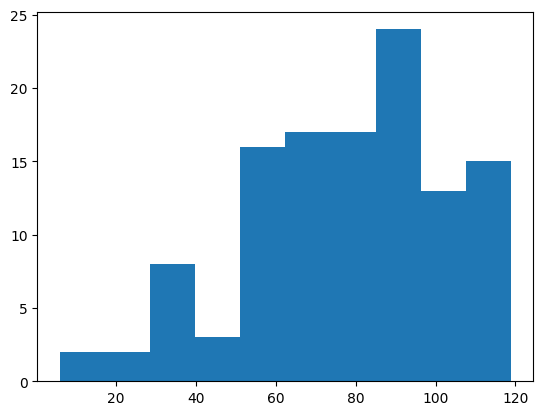

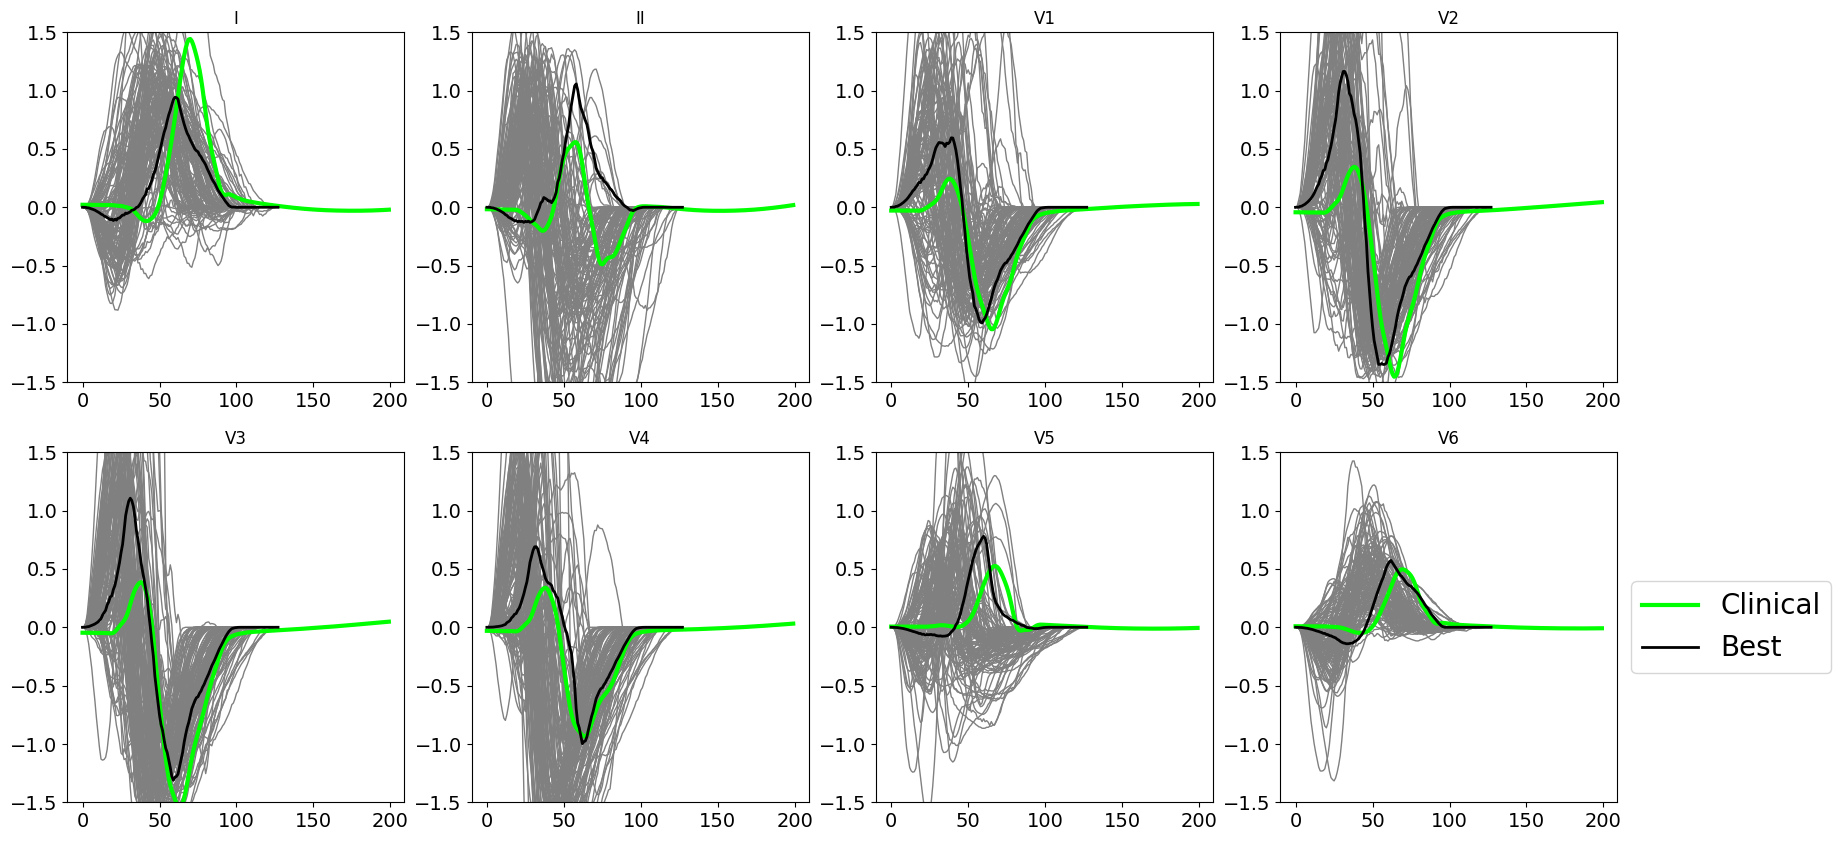

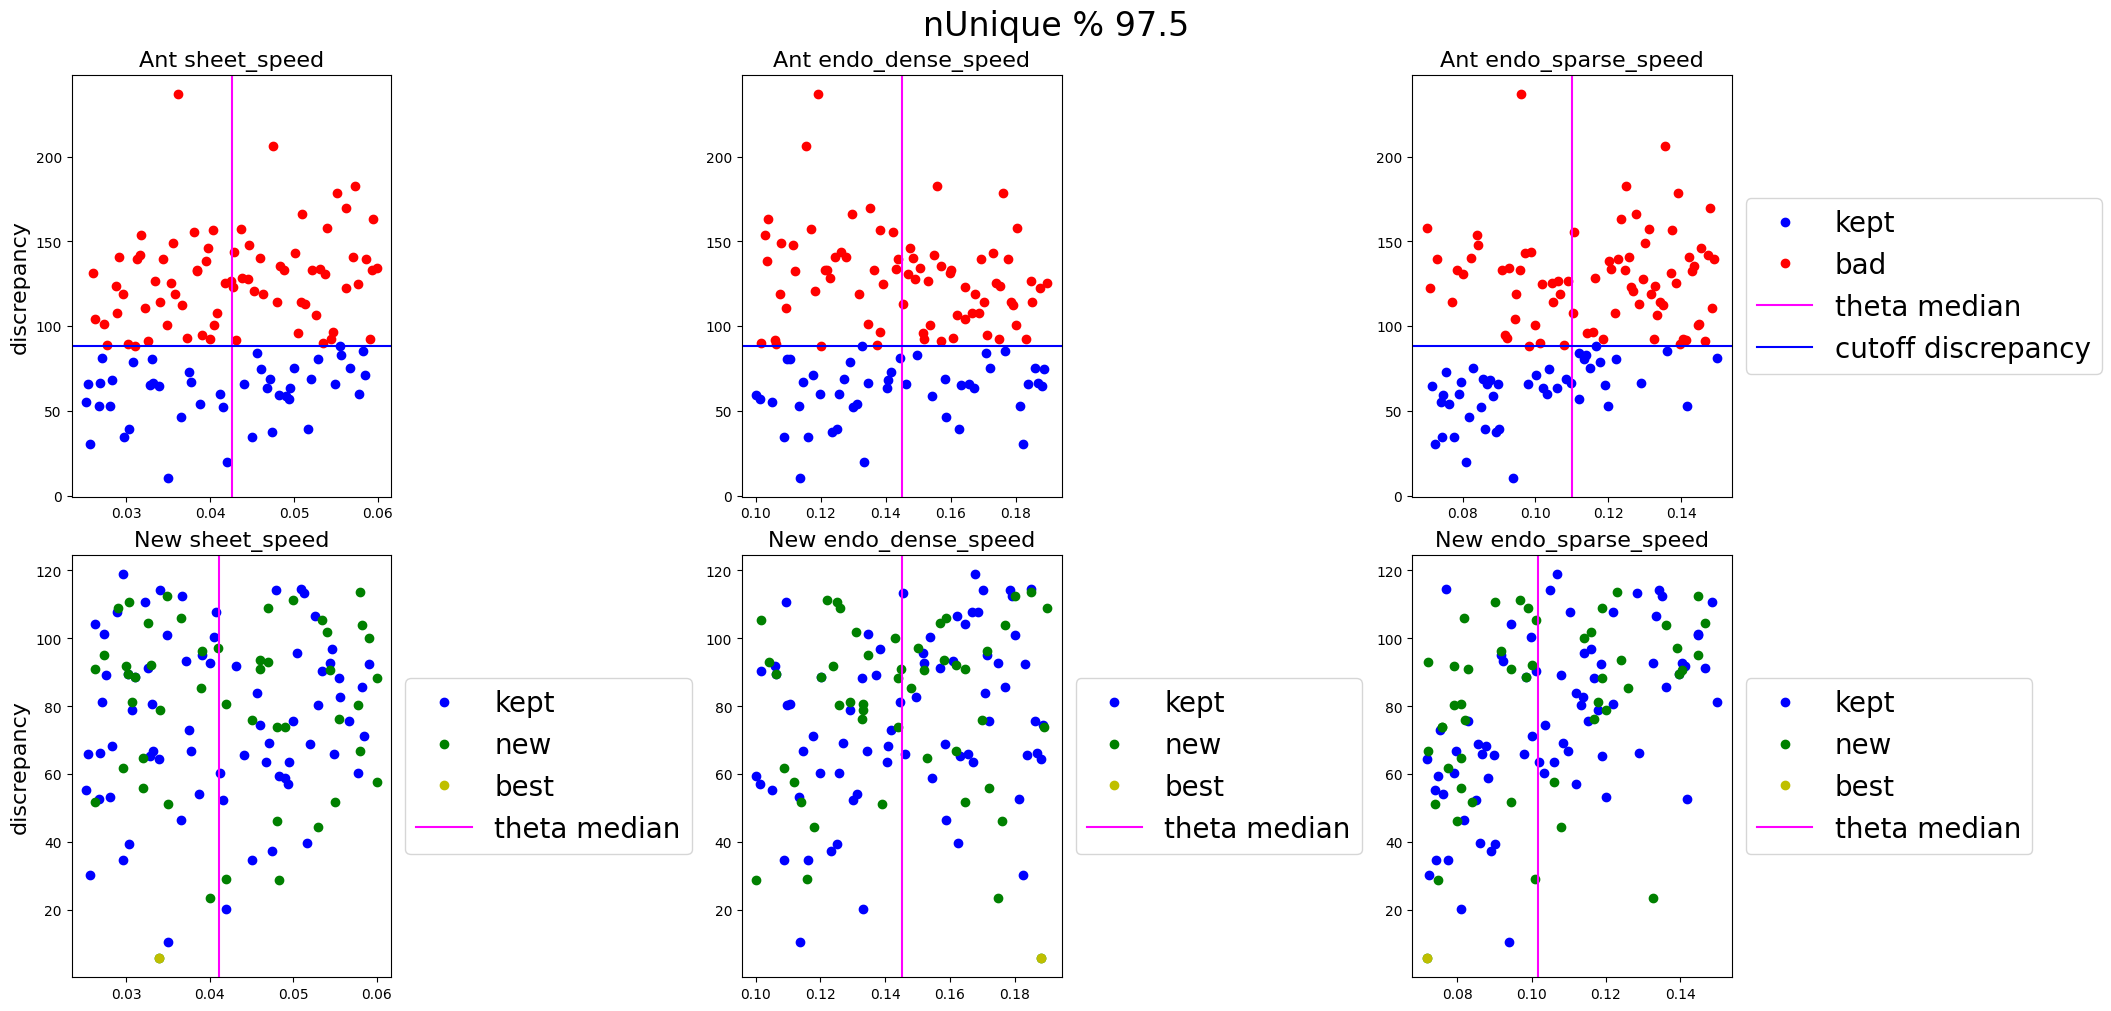

Inference iteration: 1  |  Elapsed time 0.0 hours, out of 12.0   |   Time remaining: 12.0
nb_mcmc_moves  3
nb_unique  118  , unique_lim_nb  60
cuttoff_discrepancy  89.4214315617195  , desired_discrepancy  1.0
best discrepancy  5.915536504807831
Inference iteration: 2  |  Elapsed time 0.1 hours, out of 12.0   |   Time remaining: 11.9
nb_mcmc_moves  5
nb_unique  117  , unique_lim_nb  60
cuttoff_discrepancy  69.95815401760396  , desired_discrepancy  1.0
best discrepancy  4.258081428372291
Inference iteration: 3  |  Elapsed time 0.1 hours, out of 12.0   |   Time remaining: 11.9
nb_mcmc_moves  4
nb_unique  116  , unique_lim_nb  60
cuttoff_discrepancy  57.908694243641264  , desired_discrepancy  1.0
best discrepancy  4.258081428372291
Inference iteration: 4  |  Elapsed time 0.1 hours, out of 12.0   |   Time remaining: 11.9
nb_mcmc_moves  5
nb_unique  116  , unique_lim_nb  60
cuttoff_discrepancy  48.233013283106146  , desired_discrepancy  1.0
best discrepancy  4.257259392484203
Inference itera

In [ ]:
# --- EXECUTING PHASE 1: PERSONALISE TO QRS ---
log_file_path = os.path.join(path_mapping["results_path"],"personalisation_data",subject,"qrs_stepFunction",subject+'_log_qrs_inference_'+base_configs['exp_unique_tag']+'.txt')

print(f"--- STARTING PHASE 1: QRS PERSONALIZATION FOR {subject} ---")
print(f"inference logs will be visualised here and saved to: {log_file_path}")
with Tee(log_file_path, mode="a"):
    run_qrs_personalization(
        anatomy_subject_name=subject, 
        ecg_subject_name=subject, 
        **qrs_final_config
    )

print(f"--- PHASE 1: QRS PERSONALIZATION COMPLETED FOR {subject} ---")


anatomy_subject_name:  sb4301
ecg_subject_name:  sb4301
Caution, all the hyper-parameters are set assuming resolutions of 1000 Hz in all time-series.
Script directory: /data/Cardiac-Digital-Twin/src
Working directory: /data/Cardiac-Digital-Twin/src
All imports done!
Step 2: Create Cellular Electrophysiology model, using a step function as the APs upstroke.
Initialising Cellular model
Step 3: Generate a cardiac geometry.
Reading geometry


/data/Cardiac-Digital-Twin/src/utils.py:557: UserWarning: Careful! Ventricular field ab_cut has an error in the ranges, but within the tolerace!
(Error is small) Ranges of ventricular field ab_cut are not as expected!
Expected range was [0.0, 1.0], given values ranged from 0.0005482862470672 to 1.0
  warn('Careful! Ventricular field ' + vc_name + ' has an error in the ranges, but within the tolerace!'
/data/Cardiac-Digital-Twin/src/utils.py:568: UserWarning: (Error too large) Ranges of ventricular field rt are not as expected!
Expected range was [-1.0, 1.0], given values ranged from 1.16459669e-08 to 0.9999993443489075
  warn('(Error too large) Ranges of ventricular field ' + vc_name + ' are not as expected!\nExpected range was '


Precomputing Eikonal adjacentcies
Check all nodes in the LV surface are connected
Remomve this many nodes: 11
Check all nodes in the RV surface are connected
Remomve this many nodes: 0
mean_error  0.0
Function get_node_fibre_sheet_normal() returns a node field where each entry includes the components in the fibre direction, the sheet, then normal, rather than the original fibre_fibre, fibre_sheet and fibre_normal vectors!
Check all nodes are connected
Remomve this many nodes: 0
Defining dense and sparse regions in the endocardium using ventricular coordinates
hey, check this
Reading geometry
Step 4: Create rule-based Purkinje network using ventricular coordinates.
Generating Purkinje tree
purkinje_max_ab_cut_threshold  0.8
Inside generate_candidate_root_nodes_in_cavity
Inside generate_candidate_root_nodes_in_cavity
Generating Purkinje tree
lv_candidate_root_node_meta_index  (24,)

rv_candidate_root_node_meta_index  [   2   13   31   65   75   83  105  123  286  369  467  605  711  785


/data/Cardiac-Digital-Twin/src/ecg_functions.py:935: UserWarning: This function is outdated! Use the one in preprocessing_functinos.py instead
  warn('This function is outdated! Use the one in preprocessing_functinos.py instead')


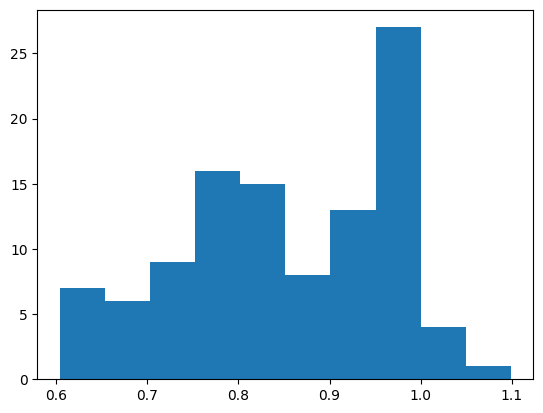

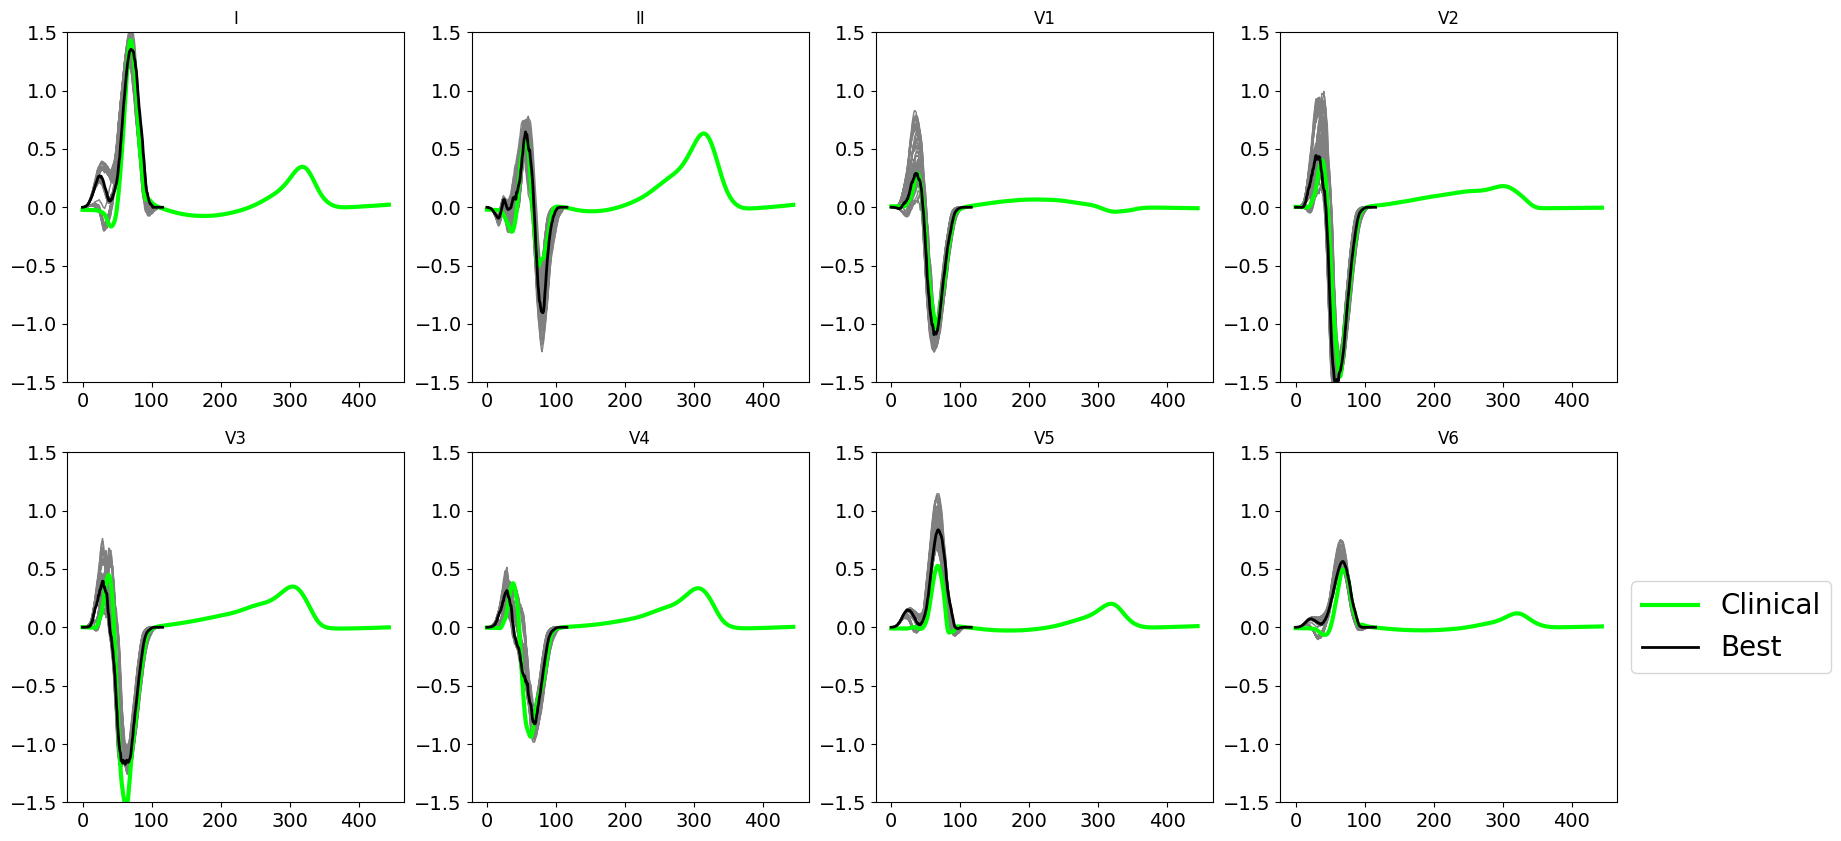

Saved ecg figure:  /data/Cardiac-Digital-Twin/cardiac-data/meta_data/results_test/personalisation_data/sb4301/qrs_stepFunction/Jun_2026/ensight/sb4301_coarse1500cm_personalisation_population.png
Step 13: Select best discrepancy particle.
Saved best parameter:  /data/Cardiac-Digital-Twin/cardiac-data/meta_data/results_test/personalisation_data/sb4301/qrs_stepFunction/Jun_2026/best_discrepancy/sb4301_coarse1500cm_personalisation-best-parameter.csv
mean_error  0.0
Saved best lat:  /data/Cardiac-Digital-Twin/cardiac-data/meta_data/results_test/personalisation_data/sb4301/qrs_stepFunction/Jun_2026/best_discrepancy/sb4301_coarse1500cm_nodefield_personalisation-lat.csv
Saved best vm:  /data/Cardiac-Digital-Twin/cardiac-data/meta_data/results_test/personalisation_data/sb4301/qrs_stepFunction/Jun_2026/best_discrepancy/sb4301_coarse1500cm_nodefield_personalisation-vm.csv
Write out geometric fields as Ensight at  /data/Cardiac-Digital-Twin/cardiac-data/meta_data/results_test/personalisation_data/

<Figure size 640x480 with 0 Axes>

In [4]:
from visualise_QRS_personalisation import visualise_qrs_personalisation
qrs_visualise_config = {
    **base_configs,
    'target_resolution': 'coarse1500cm'
}
visualise_qrs_personalisation(
    anatomy_subject_name=subject, 
    ecg_subject_name=subject, 
    **qrs_visualise_config
)

In [3]:
from ecg_functions import get_cycle_length
from utils import get_sf_iks_biomarker_name
# parameters for clinical ecg processing in twave personalisation
# by default are the same as qrs personalisation, but they can be changed if different
twave_clinical_config = {
    'clinical_ecg_filename': qrs_clinical_config['clinical_ecg_filename'], #name clinical ecg file in the folder /data/clinical_data
    #'source_resolution': qrs_clinical_config['source_resolution'],
    'filtering': qrs_clinical_config['filtering'], #filtering for the input ecg signal
    'low_freq_cut': qrs_clinical_config['low_freq_cut'],
    'high_freq_cut': qrs_clinical_config['high_freq_cut'],
    'normalise': qrs_clinical_config['normalise'], #normalising for clinical ecg signal
    'zero_align': qrs_clinical_config['zero_align'], 
    'frequency': qrs_clinical_config['frequency'],  # This is only used for filtering. If you dont use 1000 Hz in any time-series in the code, the other hyper-parameters will not give the expected outcome!
    'max_len_qrs': qrs_clinical_config['max_len_qrs'],  # in ms. This is used to crop the QRS complex from the ECG signal. It should be long enough to capture the entire QRS complex, but not too long to include the T-wave.
    'max_len_st': 300,  # in ms. This is used to crop the ST segment from the ECG signal. It should be long enough to capture the entire ST segment, but not too long to include the T-wave.
    'lead_names': qrs_clinical_config['lead_names']
}
#subject heart rate used to calculate cycle length
subject_heart_rate = 74
cycle_length = get_cycle_length(heart_rate=subject_heart_rate)
cycle_length_str = str(int(cycle_length))

# string name of cellular ep model generated from matlab for the specific cycle length
ep_model_twave_name = 'GKs5_GKr0.5_tjca60_CL_' + cycle_length_str
# parameters used to generate cellular models tables
gradient_ion_channel_list = [get_sf_iks_biomarker_name()] # default sf_IKs
gradient_ion_channel_str = '_'.join(gradient_ion_channel_list)
cellular_stim_amp = 11
cellular_model_convergence = 'not_converged'
stimulation_protocol = 'diffusion'
# relative path to cellular model csv tables in the data folder
cellular_data_relative_path = 'cellular_data/' + cellular_model_convergence + '_' + stimulation_protocol + '_' + str(
    cellular_stim_amp) + '_' + gradient_ion_channel_str + '_' + ep_model_twave_name + '/'

twave_cellular_model_config = {
    'heart_rate': 74,
    'ep_model_twave_name': ep_model_twave_name,
    'cellular_data_relative_path': cellular_data_relative_path,
}

twave_inference_ranges_config = {
    'apd_exploration_margin': 80,
    'apd_max_prior': None,  # [mean, std]
    'apd_min_prior': None,  # [mean, std]
    'g_vc_ab_range': [-1, 1], # min-max
    'g_vc_ab_prior': None,  # [mean, std]
    'g_vc_aprt_range': [-1, 1], # min-max
    'g_vc_aprt_prior': None,  # [mean, std]
    'g_vc_rvlv_range': [-1, 1], # min-max
    'g_vc_rvlv_prior': None,  # [mean, std]
    'g_vc_tm_range': [-1, 1], # min-max
    'g_vc_tm_prior': None,  # [mean, std]
}

twave_smc_inference_config = {
    'population_size': 120,
    'max_mcmc_steps': 50,   # This number allows for extensive exploration
    'retain_ratio': 0.5,    # proportion of samples that would match the current data in the case of N_on = 1 and all particles having the same variable switched on.
    'unique_stopping_ratio': 0.5, # if only 50% of the population is unique, then terminate the inference and consider that it has converged.
    'max_root_node_jiggle_rate': 0.1,
    'desired_discrepancy': 1.0,
    'max_process_alive_time': 24., # hours max inference time limit
    'visualisation_count':10,    #minimum of 1 iteration steps to visualise the results during inference
}
twave_final_config = {**base_configs, **twave_cellular_model_config, **twave_clinical_config, **twave_inference_ranges_config, **twave_smc_inference_config}


--- STARTING PHASE 2: TWAVE PERSONALIZATION FOR sb4301 ---
anatomy_subject_name:  sb4301
ecg_subject_name:  sb4301
Caution, all the hyper-parameters are set assuming resolutions of 1000 Hz in all time-series.
Script directory: /data/Cardiac-Digital-Twin/src
Working directory: /data/Cardiac-Digital-Twin/src
All imports done!
heart_rate  74
cycle_length  810.8108108108108
Step 2: Create Cellular Electrophysiology model, using a ToROrd APD dictionary.
cellular_model_name  torord_calibrated_pom_CL810
Using ToR-ORd cellular model!
Initialising Cellular model
apd_min_min  180
apd_max_max  342
Step 3: Generate a cardiac geometry that cannot run the Eikonal.
lvrv  should be lvrv instead!
Reading geometry


/data/Cardiac-Digital-Twin/src/utils.py:557: UserWarning: Careful! Ventricular field ab_cut has an error in the ranges, but within the tolerace!
(Error is small) Ranges of ventricular field ab_cut are not as expected!
Expected range was [0.0, 1.0], given values ranged from 0.0005482862470672 to 1.0
  warn('Careful! Ventricular field ' + vc_name + ' has an error in the ranges, but within the tolerace!'


Precomputing Eikonal adjacentcies
Step 4: Prepare smoothing configuration to resemble diffusion effects.
   fibre_speed  sheet_speed  normal_speed  endo_dense_speed  \
0        0.065        0.032         0.048               0.1   

   endo_sparse_speed  purkinje_speed   r0   r1   r2   r3  ...  r35  r36  r37  \
0               0.07             0.3  0.0  0.0  0.0  1.0  ...  0.0  0.0  0.0   

   r38  r39  r40  r41  r42  r43  r44  
0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  

[1 rows x 51 columns]
sheet_speed 0.032
fibre_speed 0.065
normal_speed 0.048
Precompuing the smoothing, change this please!


/data/Cardiac-Digital-Twin/src/personalise_to_Twave.py:337: UserWarning: Inference from QT can, but does NOT, update the speeds in the smoothing function!
Also, it requires some initial fixed values!
  warn('Inference from QT can, but does NOT, update the speeds in the smoothing function!\nAlso, it requires some initial fixed values!')
/data/Cardiac-Digital-Twin/src/personalise_to_Twave.py:341: UserWarning: What should be transmural and what should be sheet?
  warn('What should be transmural and what should be sheet?')
/data/Cardiac-Digital-Twin/src/geometry_functions.py:691: UserWarning: CHANGES IN CONDUCTION SPEEDS DURING THE INFERENCE CANNOT AFFECT THE SMOOTHING!!
  warn('CHANGES IN CONDUCTION SPEEDS DURING THE INFERENCE CANNOT AFFECT THE SMOOTHING!!')


Step 4: Create propagation model instance, this will be a static dummy propagation model.
Initialising Propagation
Step 5: Create Whole organ Electrophysiology model.
Initialising EP
parameter_name_list_in_order  ['apd_max', 'apd_min', 'ab_cut', 'aprt', 'lvrv', 'tm']
parameter_name_list_in_order  6
Step 6: Create ECG calculation method.
Initialising ECG calculation
Step 7: Define instance of the simulation method.
Initialising Simulator
Step 8: Define Adapter to translate between theta and parameters.
Caution: these rules have only been enabled for the inferred parameters!
Initialising Adapter
Step 9: Define the discrepancy metric.
Step 10: Create evaluator_ecg.
Initialising Evaluator
Step 11: Create instance of inference method.
multiprocessing.cpu_count()  24
population_size  120
keep_fraction  0.6
worst_keep  72
jiggle number of samples  48
Initialising Sampling Method
Initialising population
Applying boundaries or prior to Theta num  0
Using boundaries  [262, 342]
Applying boundari

/data/Cardiac-Digital-Twin/src/ecg_functions.py:935: UserWarning: This function is outdated! Use the one in preprocessing_functinos.py instead
  warn('This function is outdated! Use the one in preprocessing_functinos.py instead')


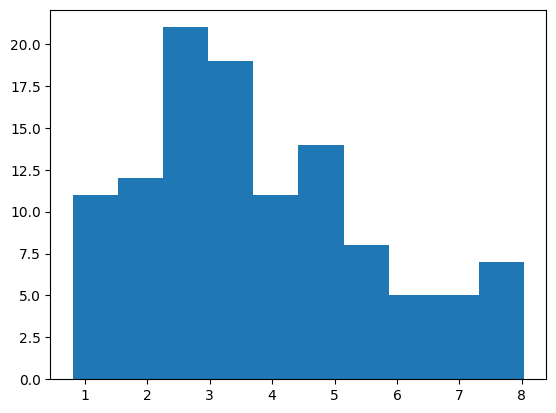

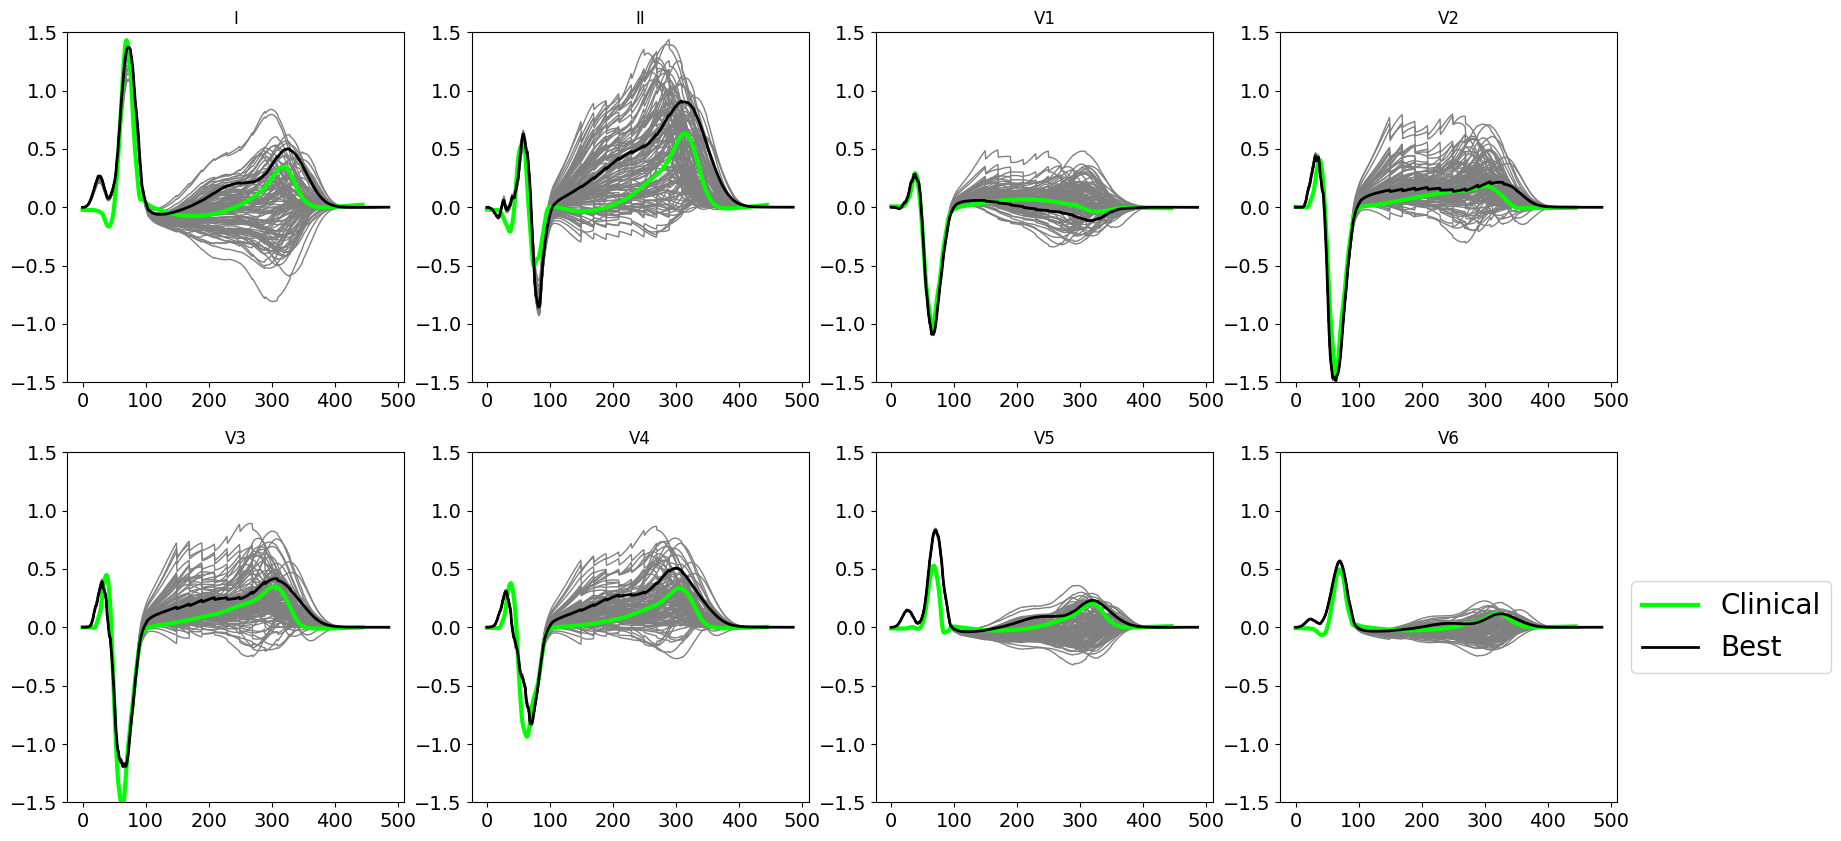

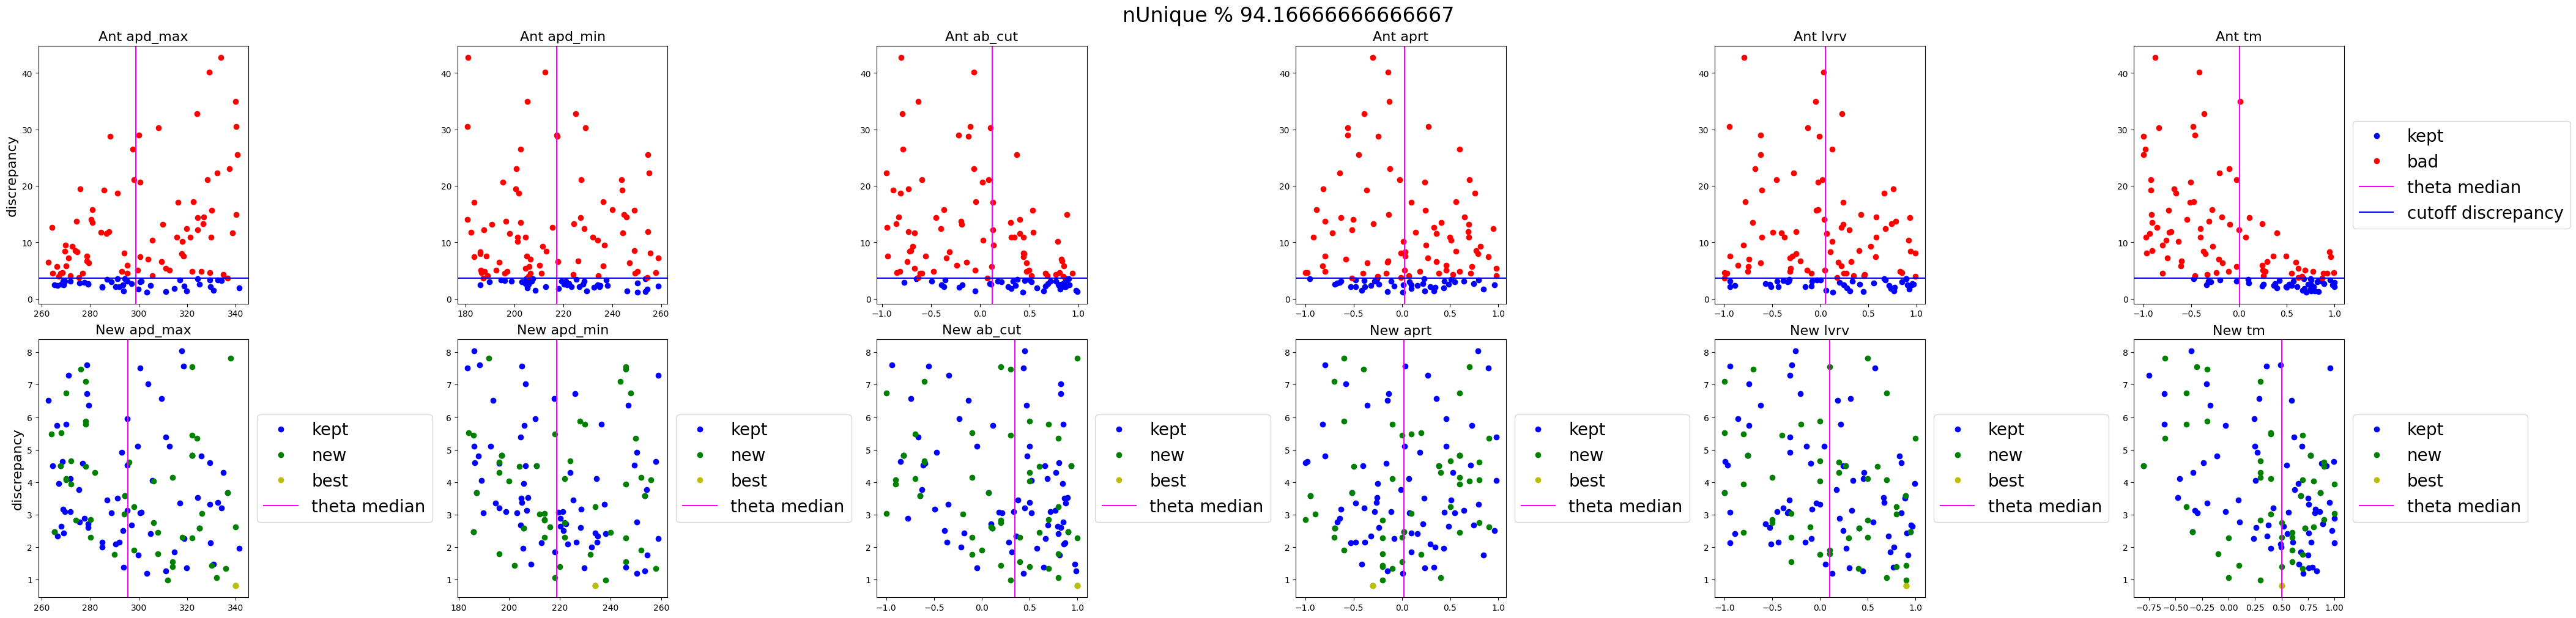

Inference iteration: 1  |  Elapsed time 0.6 hours, out of 24.0   |   Time remaining: 23.4
nb_mcmc_moves  23
nb_unique  114  , unique_lim_nb  60
cuttoff_discrepancy  4.072510024323926  , desired_discrepancy  1.0
best discrepancy  0.811480828309142
Inference iteration: 2  |  Elapsed time 1.2 hours, out of 24.0   |   Time remaining: 22.8
nb_mcmc_moves  9
nb_unique  110  , unique_lim_nb  60
cuttoff_discrepancy  2.8703082876770902  , desired_discrepancy  1.0
best discrepancy  0.7998711467827629
Inference iteration: 3  |  Elapsed time 1.4 hours, out of 24.0   |   Time remaining: 22.6
nb_mcmc_moves  47
nb_unique  118  , unique_lim_nb  60
cuttoff_discrepancy  2.2925622503258505  , desired_discrepancy  1.0
best discrepancy  0.7998711467827629
Inference iteration: 4  |  Elapsed time 2.6 hours, out of 24.0   |   Time remaining: 21.4
nb_mcmc_moves  35
nb_unique  117  , unique_lim_nb  60
cuttoff_discrepancy  1.7762328693781564  , desired_discrepancy  1.0
best discrepancy  0.7998711467827629
Inferen

In [ ]:
log_file_path = os.path.join(path_mapping["results_path"],'personalisation_data',subject,'twave_' + gradient_ion_channel_str + '_' + ep_model_twave_name,subject+'_log_twave_inference_'+base_configs['exp_unique_tag']+'.txt')

# --- EXECUTING PHASE 2: PERSONALISE TO TWAVE ---

print(f"--- STARTING PHASE 2: TWAVE PERSONALIZATION FOR {subject} ---")
with Tee(log_file_path, mode="a"):
    run_twave_personalization(
        anatomy_subject_name=subject, 
        ecg_subject_name=subject, 
        **twave_final_config
    )

print(f"--- PHASE 2: TWAVE PERSONALIZATION COMPLETED FOR {subject} ---")


In [ ]:
from visualise_Twave_personalisation_history import visualise_Twave_personalisation_history

qrs_visualise_config = {
    **base_configs,
    **twave_cellular_model_config,
    'inference_resolution': 'coarse1500cm'
}
visualise_Twave_personalisation_history(anatomy_subject_name=subject, ecg_subject_name=subject)

anatomy_subject_name:  sb4301
ecg_subject_name:  sb4301
Caution, all the hyper-parameters are set assuming resolutions of 1000 Hz in all time-series.
Script directory: /data/Cardiac-Digital-Twin/src
Working directory: /data/Cardiac-Digital-Twin/src
All imports done!
ep_model_twave_name  GKs5_GKr0.5_tjca60_CL_810
Step 2: Create Cellular Electrophysiology model, using a ToROrd APD dictionary.
ep_model  GKs5_GKr0.5_tjca60_CL_810
Initialising Cellular model


Step 3: Generate a cardiac geometry.
Reading geometry


/data/Cardiac-Digital-Twin/src/utils.py:557: UserWarning: Careful! Ventricular field ab_cut has an error in the ranges, but within the tolerace!
(Error is small) Ranges of ventricular field ab_cut are not as expected!
Expected range was [0.0, 1.0], given values ranged from 0.0005482862470672 to 1.0
  warn('Careful! Ventricular field ' + vc_name + ' has an error in the ranges, but within the tolerace!'
